In [1]:
import json
import pandas as pd
from neo4j import GraphDatabase

In [2]:
graph = GraphDatabase.driver("neo4j://localhost:7687", auth=("neo4j", "test"), encrypted=False)

The next 3 cells have been useful during the developing process. 

The first deletes everything.

The second one deletes all the tweets.

The third one deletes all the users.

In [3]:
with graph.session() as session:
    session.run("MATCH (n) DETACH DELETE n")

In [4]:
with graph.session() as session:
    session.run("MATCH (n:Tweet) DETACH DELETE n")

In [5]:
with graph.session() as session:
    session.run("MATCH (n:User) DETACH DELETE n")

Function to create an user node

In [6]:
def create_user(tx,username):
    return tx.run("CREATE (a:User {username:$username})" 
                  "RETURN id(a)", username=username).single().value()

Function to create a tweet node

In [7]:
def create_tweet(tx,text,likes,retweets,replies,mention):
    return tx.run("CREATE (a:Tweet {text:$text,likes:$likes,retweets:$retweets, replies:$replies, mention:$mention})" 
                  "RETURN id(a)", text=text,likes=likes,retweets=retweets, replies=replies, mention=mention).single().value()

Create reletionships

In [8]:
def mention(tx,text,username):
    return tx.run("MATCH (a:Tweet {text: $text})"
                  "MATCH (b:User {username: $username})"
                  "CREATE (a)-[r:MENTION]->(b)"
                  "RETURN type(r)", text=text, username=username).single().value()

In [9]:
def follows(tx,a_username,b_username):
    return tx.run("MATCH (a:User {username: $a_username})"
                  "MATCH (b:User {username: $b_username})"
                  "CREATE (a)-[r1:FOLLOWS]->(b)"
                  "RETURN type(r1)", a_username=a_username, b_username=b_username).single().value()

In [10]:
def posts(tx,username,text):
    return tx.run("MATCH (a:User {username: $username})"
                  "MATCH (b:Tweet {text: $text})"
                  "CREATE (a)-[r1:POSTS]->(b)"
                  "RETURN type(r1)", username=username, text=text).single().value()

We don't want duplicates users in our database, hence we create a constraint to avoid them.

In [11]:
with graph.session() as session:
    session.run("CREATE CONSTRAINT FOR (n:User) REQUIRE n.username IS UNIQUE")

ClientError: {code: Neo.ClientError.Schema.EquivalentSchemaRuleAlreadyExists} {message: An equivalent constraint already exists, 'Constraint( id=4, name='constraint_681a03be', type='UNIQUENESS', schema=(:User {username}), ownedIndex=3 )'.}

Creating user nodes for dr_jpe and Elon Musk

In [12]:
with graph.session() as session:
    # some nodes have extra attributes (e.g. email)
    jp_node_id = session.execute_write(create_user, "@dr_jpe")
    elon_node_id = session.execute_write(create_user, "@elonmusk") 

In [13]:
with graph.session() as session:
    session.execute_write(follows,"@dr_jpe","@elonmusk") 

Store tweets

In [14]:
df = pd.read_csv('elon-cleaned.csv')

In [15]:
df=df.drop('Unnamed: 0', axis=1)
df

,Tweet,Likes,Retweet,Reply,Mention
0,@Twitter And many other features to come!,24493,1668,2587,@Twitter
1,https://t.co/80DdvpsNjM,616866,65419,19446,No mention
2,Twitter is both a social media company and a c...,659791,91219,34773,No mention
3,@elizableu Looks like Yoel is arguing in favor...,59350,14687,5821,@elizableu
4,@elizableu This explains a lot,90564,6867,1611,@elizableu
...,...,...,...,...,...
15630,@mhmtkcn Near 405,1151,28,47,@mhmtkcn
15631,https://t.co/3k71xzDIP1,26042,3492,609,No mention
15632,Falcon Heavy goes vertical https://t.co/uG1k0W...,80725,13908,1976,No mention
15633,Using a neural net to detect rain using camera...,16471,2170,655,No mention


Create tweets with all the metrics.

Create the relationship 'POSTS' between Elon and the tweets

Create each user mentioned in the tweets

Create each the relationship 'MENTION' between the tweets and the respective users mentioned in it

In [16]:
with graph.session() as session:
    for i,row in df.iterrows():
        session.execute_write(create_tweet,df['Tweet'].values[i],int(df['Likes'].values[i]),int(df['Retweet'].values[i]),
        int(df['Reply'].values[i]),df['Mention'].values[i])
        
        session.execute_write(posts,"@elonmusk",df['Tweet'].values[i])
        
        if df['Mention'].values[i] != 'No mention':
            try:
                session.execute_write(create_user, df['Mention'].values[i])        
            except:
                pass
            
            session.execute_write(mention,df['Tweet'].values[i],df['Mention'].values[i])
      

/home/michele/anaconda3/envs/cps3235/lib/python3.9/site-packages/neo4j/_sync/work/result.py:461: UserWarning: Expected a result with a single record, but found multiple.
  warn("Expected a result with a single record, "


Get followers from our file

In [17]:
followers =[]
with open("followers_cleaned","r") as fp:
    followers=json.load(fp)

In [18]:
len(followers)

33015

Create user node for each follower

In [19]:
with graph.session() as session:
    for i in followers:
        try:
            session.execute_write(create_user, i)
        except:
            pass

Create relationship 'FOLLOWS' between each follower and Elon

In [20]:
with graph.session() as session:
    for i in followers:
        try:
            session.execute_write(follows,i,"@elonmusk")            
        except:
            pass

Store following

In [21]:
following =[]
with open("following_cleaned","r") as fp:
    following=json.load(fp)

Create relationship 'FOLLOWS' between Elond each user he is following

In [22]:
with graph.session() as session:
    for i in following:
        try:
            session.execute_write(create_user, i)
            session.execute_write(follows,"@elonmusk",i) 
        except:
            pass

TASK C

WE ARE GOING TO GET THE 5 FIVE MOST LIKED, MOST RETWEETED AND MOST REPLIED.

For a total of 15 tweets


In [42]:
def get_most_liked(tx):
    most_liked = []
    for record in tx.run("MATCH (n:Tweet) WITH n ORDER BY n.likes DESC RETURN n LIMIT 5"):
        print(record[0]['text'])
        most_liked.append(record[0]['text'])
    return most_liked

In [43]:
with graph.session() as session:
    session.execute_read(get_most_liked)  

Next I’m buying Coca-Cola to put the cocaine back in
I hope that even my worst critics remain on Twitter, because that is what free speech means
Let’s make Twitter maximum fun!
🚀💫♥️ Yesss!!! ♥️💫🚀 https://t.co/0T9HzUHuh6
Listen, I can’t do miracles ok https://t.co/z7dvLMUXy8


In [49]:
def get_most_replied(tx):
    most_replied = []
    for record in tx.run("MATCH (n:Tweet) WITH n ORDER BY n.replies DESC RETURN n LIMIT 5"):
        print(record[0]['text'])
        most_replied.append(record[0]['text'])
    return most_replied

with graph.session() as session:
    session.execute_read(get_most_replied) 

What should Twitter do next?
Reinstate former President Trump
Next I’m buying Coca-Cola to put the cocaine back in
I hope that even my worst critics remain on Twitter, because that is what free speech means
What is best in life?


In [50]:
def get_most_retweeted(tx):
    most_retweeted = []
    for record in tx.run("MATCH (n:Tweet) WITH n ORDER BY n.retweets DESC RETURN n LIMIT 5"):
        print(record[0]['text'])
        most_retweeted.append(record[0]['text'])
    return most_retweeted

with graph.session() as session:
    session.execute_read(get_most_retweeted) 

Next I’m buying Coca-Cola to put the cocaine back in
I hope that even my worst critics remain on Twitter, because that is what free speech means
the bird is freed
🚀💫♥️ Yesss!!! ♥️💫🚀 https://t.co/0T9HzUHuh6
Had to been done ur welcome https://t.co/7jT0f9lqIS


TASK D

In [51]:
def get_text(tx):
    texts = []
    for record in tx.run("MATCH (n:Tweet) RETURN n"):
        texts.append(record[0]['text'])
    return texts

In [52]:
all_texts = []

In [55]:
with graph.session() as session:
    all_texts = session.execute_read(get_text)

@Twitter And many other features to come!
https://t.co/80DdvpsNjM
Twitter is both a social media company and a crime scene
@elizableu Looks like Yoel is arguing in favor of children being able to access adult Internet services in his PhD thesis: https://t.co/1NiBohjhMQ
@elizableu This explains a lot
https://t.co/xKmQ8m7uHq
🇲🇦🇲🇦 Congrats Morocco!! 🇲🇦🇲🇦
@pepesgrandma @tedlieu Interesting, how so?
@TomFitton @realDonaldTrump @Twitter Coming soon …
@cancelmyfunera1 @SirineAti @coffeetabletsla @tedlieu Yeah
@wintonARK Fate 🖤 Irony
@coffeetabletsla @tedlieu Good po1nt
@tedlieu Hey stop gaslighting me!
@nichegamer It’s almost ready
@DomaineValescia At least! 🤣
@nichegamer We seriously need long-form tweets!
@sparklingruby Worth a read
@ZacksJerryRig Do I think Trump would have lost anyway? Yes. And, as a reminder, I supported Biden, Hilary and Obama.

Nonetheless, election interference by social media companies obviously undermines the public’s faith in democracy and is wrong.
@TomFitton @Twi

@chicago_glenn .@Twitter what’s going on?
@TrungTPhan @McDonalds Such miracles are impossible
@ruffpast @stevenmarkryan @SawyerMerritt @mayemusk @RBReich @PenguinBooks That’s a real picture?
@stevenmarkryan @SawyerMerritt @mayemusk @RBReich @PenguinBooks Absolutely
@jhall @RBReich Unsurprisingly, Reich is also a hypocrite
@teslaownersSV @RBReich Reich is suicidally boring
@TrungTPhan 🤣
@RBReich You both an idiot and a liar
@BillyM2k 🤣
@ajtourville @parag @Twitter Curiouser and curiouser …
@BillyM2k @Austen Same
@BLKMDL3 @teslascope @johnkrausphotos Yes
@ToscaMusk @kimbal Happy birthday bro, love you
@teslascope @johnkrausphotos Yes, all US &amp; Canada cars with safety scores above 80 should receive an invitation to download FSD Beta by tomorrow
@teslaownersSV @johnkrausphotos Note, Autopilot/AI team is also working on Optimus and (actually smart) summon/autopark, which have end of month deadlines
@teslaownersSV @johnkrausphotos Next month
@johnkrausphotos Yes
@agusantonetti @erfan_kas

@JohnnaCrider1 @POTUS Teslas are the most made-in-USA vehicles
@ChildrensHD Total scam
@mn_google My calves are bigger tho
To think that Fremont was just a derelict building &amp; Giga Nevada was just rocks &amp; bushes when started!

California used to have a dozen car factories. NUMMI was last to close. Now, Tesla Fremont is the biggest car factory in North America!
Congrats to Tesla Fremont + Giga Nevada for making their 2 millionth car!
Please vote your shares with Tesla! https://t.co/ZbFWv0pkgG
@WholeMarsBlog Yeah
@SawyerMerritt @SpaceX It’s a start. About 1000 times more mass to orbit per year will be needed to make life multiplanetary.
@BillyM2k Already did it
@Teslaconomics Haha damn, maybe I should take off my shirt more often … free the nip!! 
(already back in the factory btw)
@teslaownersSV Still needs a few tweaks
@JohnnaCrider1 @TwitterSupport @Teslarati @WholeMarsBlog 🤔
https://t.co/8IYBfjFact
@EvaFoxU @BillyM2k 💯🤣
@RenataKonkoly @engineers_feed A classic 🤣
@engineers_fee

@harald_murphy @SpaceX @Tesla @Jays200 A lot of improvement still coming just from software updates to satellites &amp; terminals
@Erdayastronaut I talked about Falcon 9 &amp; Heavy for over a decade!
@PPathole Still kinda hard to believe it is working
@PPathole @SpaceX Absolutely
100th SpaceX rocket landing was today https://t.co/ysO9siYCee
@BillyM2k Just keep going. It’s in there somewhere. https://t.co/jSLEIcXji1
@jack m something something
Has anyone seen web3? I can’t find it.
@BillyM2k With Starlink, you could stream video &amp; play online games
🤣🤣 True. Ask your airline for Starlink! https://t.co/R9GL2bKOAT
@omarsar0 👍
@JayinShanghai Sometime in 2022
@BillyM2k 🤣
@imoriginalankit Maybe I’m partly Chinese!
For those wondering, I will pay over $11 billion in taxes this year
@lexfridman Yeah
I’m not suggesting web3 is real – seems more marketing buzzword than reality right now – just wondering what the future will be like in 10, 20 or 30 years. 2051 sounds crazy futuristic!
@WorldA

@Model3Owners Tesla sure would appreciate changing the law, so that this is not required!
@waitbutwhy @poweredbyart Exactly
@RationalEtienne @SciGuySpace Potentially, 1000 times higher
@AlexSvanArt @Neopork85 Pretty close. No tiles on back side of flaps. Some tiles towards leeward side of ship trailing plasma spilling off rear of flaps.
@SciGuySpace Cumulative payload to orbit is the really crazy number. Falcon has delivered more than double rest of world combined over trailing 12 months.
@BTC_Archive 🤣🤣
If only they had spaceships, they’d still be around
Deep thots https://t.co/J5mJff7IIL
@WholeMarsBlog Not sure who wrote this, but it’s accurate https://t.co/gRvWxOJZ56
@Caspar_Stanley @Erdayastronaut @SpaceX @SuperHeavyBN3 Yup
@Astro_Elliott @Teslarati @ResidentSponge Aiming to have hot gas thrusters on booster for first orbital flight
@IlyaRosenberg @Caspar_Stanley @Erdayastronaut @SpaceX @SuperHeavyBN3 They are now the same (LOX below CH4). Ox is 3.5 times heavier than fuel, so make

@garyblack00 The only publicly traded stock I own is Tesla
@garyblack00 Wise words from Bogle. The point of companies is products &amp; services. They have no point in &amp; of themselves, nor do these indices. Buy &amp; hold stock in companies where you love the product roadmap, sell where you don’t.
https://t.co/yHVQJXTahn
@teslaownerssv @AstroJordy @flcnhvy No, just a mild cold. Same with my bro. Def had cov2 though. Pc&lt;20 means viral load of &gt;10 million per mL.
@Astronomiaum Life in glass domes at first. Eventually, terraformed to support life, like Earth.
@AstroJordy @flcnhvy Yeah
@Daywalker_xD @Astronomiaum I was going to say “Sim!”, but that seemed too obvious haha
@Astronomiaum Deveras!
@flcnhvy And cases with high (non-infectious) Ct should quarantine for a few days, while getting another test. Second test determines whether they’re just beginning to get ill or are on the long tail afterwards, where viral fragments exist, but person is not infectious.
@nichegamer Maybe a

@tobyliiiiiiiiii @Kristennetten @thirdrowtesla @Tesla Yeah, and whole lot more! Aargh, I’m dying to make Cybertruck like yesterday!!
@teslaownersSV @Kristennetten @thirdrowtesla @Tesla Thinking about this …
@Kristennetten @thirdrowtesla @Tesla This is the key paragraph https://t.co/zvTWhPVcM4
@alvianchoiri @Erdayastronaut @BocaChicaGal @NASASpaceflight @SpaceX Pretty much
@Erdayastronaut @BocaChicaGal @NASASpaceflight @SpaceX Mechanically attached to steel studs. Insulation is certainly the intention!
Best political platform ever https://t.co/CRbNFdQj4B
@Erdayastronaut @teslaownersSV @NASA SpaceX has a lot of experience berthing &amp; now docking with @Space_Station, which is very difficult. Orbital refilling should in theory be easier, since Starships dock with themselves &amp; will be uncrewed at first.
@RationalEtienne @teslaownersSV @Erdayastronaut Great platform 🤣🤣
@Johnny_Detroit @WhatsupFranks @flcnhvy !!
@teslaownersSV @Erdayastronaut Fully reusable orbital rocket, then orbital

@konrad_bilinski Gasoline is designed to burn
@ElecVehicleGuy @Tesla Anywhere insurance prices are high
@Sofiaan @flcnhvy @coolsilver @Tesla Yeah, several. Smart Summon most significant.
@flcnhvy @coolsilver @Tesla Both 🍀 and 😋 buttons in V10.0
@teslaownersSV @tesla_truth Yup
@coolsilver @Tesla Yes
@tesla_truth Definitely
Try Tesla Insurance. Should be ~20% less than avg. Currently only in California, but expanding soon. Critical feedback much appreciated. https://t.co/L8xv8vxllj
@HjorturBrynjars @Tesla Opening on 9/9
@fermatslibrary Slowpoke! Didn’t even finish his hypothesis …
Haha actually true https://t.co/VNB822fpPT
@vincent13031925 So good!
https://t.co/tndaPd6d8z https://t.co/G98dOzgWTv
@tesla_truth Exactly
@WadeAndersonPT @Tesla Coming soon. Version 10.1 at latest.
@Model3Owners @Tesla Yes
@PatrickMJanson 🇮🇸 Iceland 🇮🇸 for sure!
@HjorturBrynjars @enn_nafnlaus @Tesla Very soon, sorry for the delay
@JaneidyEve @flcnhvy @Freiraum77 @SpaceX Aiming for 20km flight in Oct &amp; orbit

@Malcolmmarsman @TheMuddySchmuck @martinengwicht @Erdayastronaut @NASASpaceflight @JeromeJaccard @Robotbeat @alan1bernard This test hopper is at full body diameter of 9m / 30 ft, just not full height. Super Heavy will be full height &amp; diameter.
@thescalex @Jonas123denmark @Erdayastronaut @NASASpaceflight @JeromeJaccard @Robotbeat @alan1bernard Exactly
@martinengwicht @Erdayastronaut @NASASpaceflight @JeromeJaccard @Robotbeat @alan1bernard For sheet/plate, at supplier made to our spec. For cast, in our Hawthorne foundry.
@johnkrausphotos @Erdayastronaut @NASASpaceflight @JeromeJaccard @Robotbeat @alan1bernard Yes
@Erdayastronaut @NASASpaceflight @JeromeJaccard @Robotbeat @alan1bernard I will do a full technical presentation of Starship after the test vehicle we’re building in Texas flies, so hopefully March/April
@Erdayastronaut @JeromeJaccard @Robotbeat @alan1bernard While there are some material similarities, Starship is very different from the Atlas design
@Erdayastronaut @Jerome

In [56]:
len(all_texts)

15635

In [57]:
from wordcloud import WordCloud,STOPWORDS
import re 
import matplotlib.pyplot as plt

Reference to this function: https://betterprogramming.pub/detecting-sentiment-from-elon-musks-tweets-using-python-ec7820469ac0

In [1]:
def clean_tweets(tweet):
    tweet = re.sub(r"@[A-Za-z0-9]+", "", tweet) # Remove Mentions
    tweet = re.sub(r"#", "", tweet) # Remove Hashtags Symbol
    tweet = re.sub(r"RT[\s]+", "", tweet) # Remove Retweets
    tweet = re.sub(r"https?:\/\/\S+", "", tweet) # Remove The Hyper Link
    
    return tweet

In [60]:
for i in range(len(all_texts)):
    all_texts[i] = clean_tweets(all_texts[i])

In [62]:
stopwords=set(STOPWORDS)
stopwords.update(["amp"])

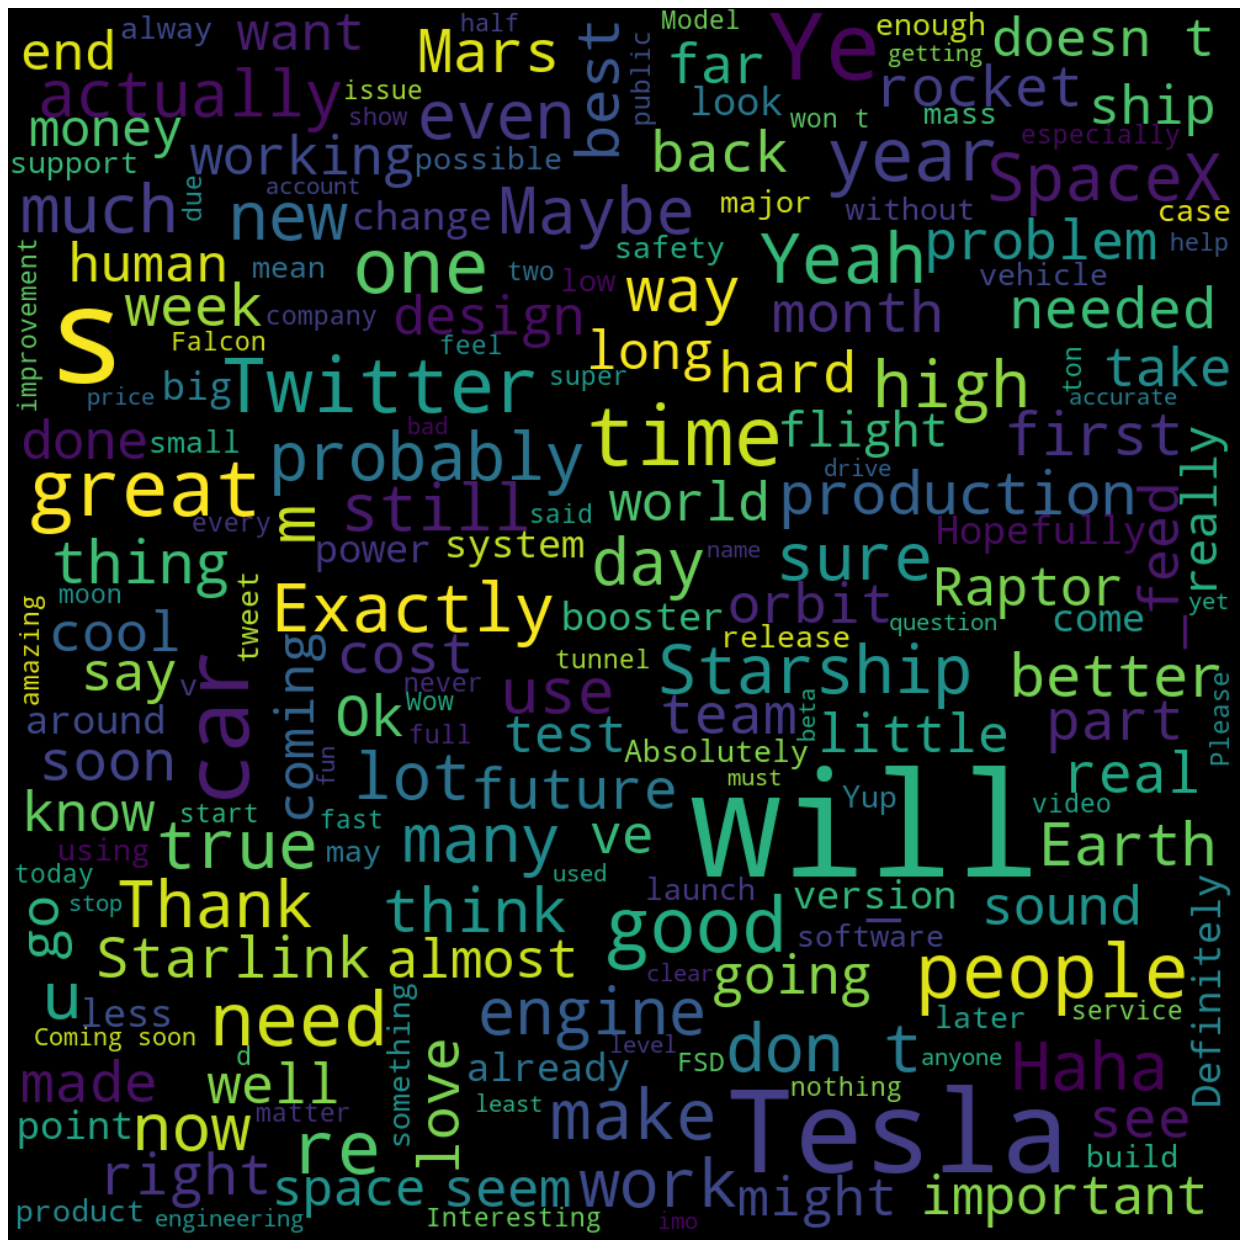

In [64]:
allwords = " ".join([twts for twts in all_texts])
wordCloud = WordCloud(width = 1000,stopwords=stopwords, height = 1000, random_state = 21, max_font_size = 119).generate(allwords)
plt.figure(figsize=(20, 20), dpi=80)
plt.imshow(wordCloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

To be more specific we can update the stopwords with useless word

In [66]:
stopwords.update(["re","doesn t","will","ok","go","Maybe","one","almost","u"])

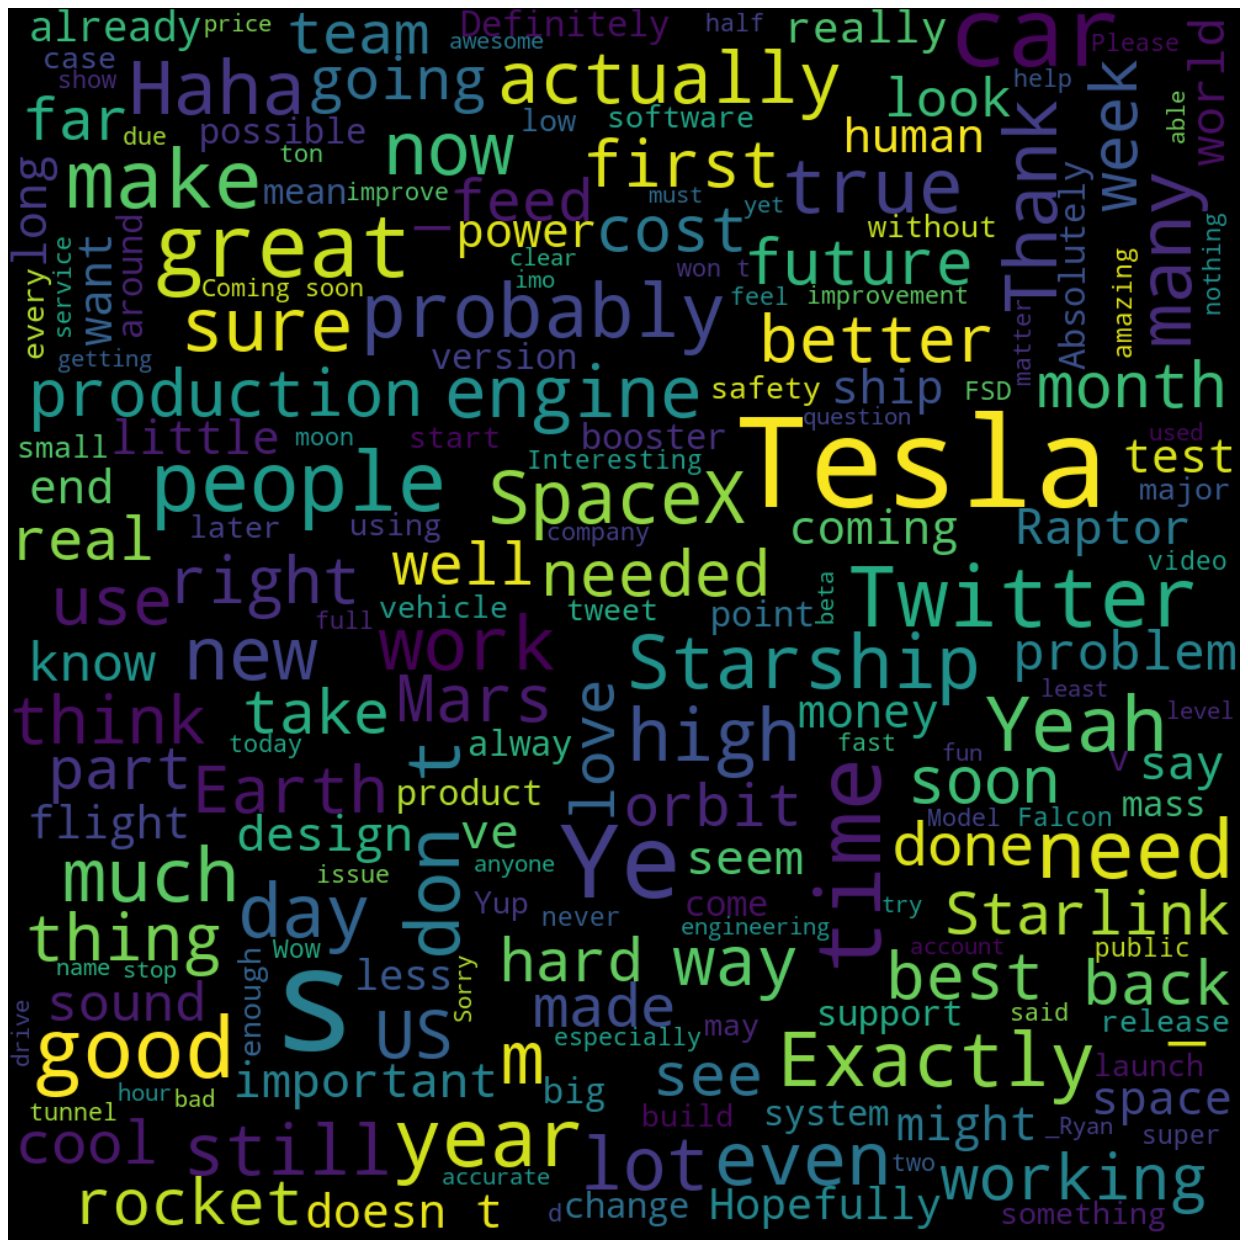

In [67]:
allwords = " ".join([twts for twts in all_texts])
wordCloud = WordCloud(width = 1000,stopwords=stopwords, height = 1000, random_state = 21, max_font_size = 119).generate(allwords)
plt.figure(figsize=(20, 20), dpi=80)
plt.imshow(wordCloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

TASK E

In [20]:
df_jpe = pd.read_csv('jpe.csv')
df_jpe = df_jpe.drop('Unnamed: 0', axis=1)
df_jpe

,Date,Tweet,Likes,Retweet,Reply,Mention
0,2022-12-10 08:07:07+00:00,"Our book chapter ""#ML for Metabolomic Pathway ...",8,0,0,"[User(username='UMmalta', id=608929606, displa..."
1,2022-12-07 11:23:12+00:00,Christmas would not be the same without the #A...,2,1,0,No mention
2,2022-12-06 12:51:24+00:00,"@dwejjaq_enormi if you have to explain it, it'...",0,0,0,"[User(username='dwejjaq_enormi', id=1337414734..."
3,2022-11-23 20:25:15+00:00,Come at @UMmalta to work on some #Bioinformati...,3,2,0,"[User(username='UMmalta', id=608929606, displa..."
4,2022-11-18 12:44:41+00:00,I would say I am at least at lvl5\nhttps://t.c...,0,0,0,No mention
5,2022-11-15 10:36:09+00:00,#CPS3235 Assignment. @elonmusk is king.,1,0,1,"[User(username='elonmusk', id=44196397, displa..."
6,2022-11-15 08:36:30+00:00,These are *read* emails. @airmalta why do you...,2,0,3,"[User(username='AirMalta', id=145612989, displ..."
7,2022-11-15 04:57:06+00:00,@TheMarvel91 @Campanelli11 Ma anche un banalis...,0,0,0,"[User(username='TheMarvel91', id=1377942848, d..."
8,2022-10-14 19:37:26+00:00,@drmenguin I'm always game to some \LaTeX fun 😂,3,0,0,"[User(username='drmenguin', id=120147583705858..."
9,2022-10-14 11:04:06+00:00,Great to see @danvlla with his few-shot #Machi...,6,2,1,"[User(username='danvlla', id=531209629, displa..."


Cleaning the dataframe

In [21]:
def split_after(my_list,separator):    
    for i,s in enumerate(my_list):
        if separator in s:
            my_list[i] = s.split(separator,1)[1] 
        
def split_before(my_list,separator):    
    for i,s in enumerate(my_list):
        if separator in s:
            my_list[i] = s.split(separator,1)[0]
        
def remove_character(my_list,to_rem):
    for i,s in enumerate(my_list):
        if to_rem in s:
            my_list[i] = s.replace(to_rem,'')

In [22]:
mention_arr = df_jpe['Mention'].to_numpy()

In [23]:
split_before(mention_arr,',')

In [24]:
split_after(mention_arr,'=')

In [25]:
remove_character(mention_arr,'\'')
for i,s in enumerate(mention_arr):
    if s != 'No mention':
        mention_arr[i] ="@"+s

In [26]:
df_jpe['Mention'] = mention_arr.tolist()

In [27]:
df_jpe

,Date,Tweet,Likes,Retweet,Reply,Mention
0,2022-12-10 08:07:07+00:00,"Our book chapter ""#ML for Metabolomic Pathway ...",8,0,0,@UMmalta
1,2022-12-07 11:23:12+00:00,Christmas would not be the same without the #A...,2,1,0,No mention
2,2022-12-06 12:51:24+00:00,"@dwejjaq_enormi if you have to explain it, it'...",0,0,0,@dwejjaq_enormi
3,2022-11-23 20:25:15+00:00,Come at @UMmalta to work on some #Bioinformati...,3,2,0,@UMmalta
4,2022-11-18 12:44:41+00:00,I would say I am at least at lvl5\nhttps://t.c...,0,0,0,No mention
5,2022-11-15 10:36:09+00:00,#CPS3235 Assignment. @elonmusk is king.,1,0,1,@elonmusk
6,2022-11-15 08:36:30+00:00,These are *read* emails. @airmalta why do you...,2,0,3,@AirMalta
7,2022-11-15 04:57:06+00:00,@TheMarvel91 @Campanelli11 Ma anche un banalis...,0,0,0,@TheMarvel91
8,2022-10-14 19:37:26+00:00,@drmenguin I'm always game to some \LaTeX fun 😂,3,0,0,@drmenguin
9,2022-10-14 11:04:06+00:00,Great to see @danvlla with his few-shot #Machi...,6,2,1,@danvlla


Creating each user dr_jpe mentions and the respective relationship

In [28]:
with graph.session() as session:
    for i,row in df_jpe.iterrows():
        session.execute_write(create_tweet,df_jpe['Tweet'].values[i],int(df_jpe['Likes'].values[i]),int(df_jpe['Retweet'].values[i]),
        int(df_jpe['Reply'].values[i]),df_jpe['Mention'].values[i])
        
        session.execute_write(posts,"@dr_jpe",df_jpe['Tweet'].values[i])
        
        if df_jpe['Mention'].values[i] != 'No mention':
            try:
                session.execute_write(create_user, df_jpe['Mention'].values[i])
                       
            except:
                pass
            
            session.execute_write(mention,df_jpe['Tweet'].values[i],df_jpe['Mention'].values[i])

Query to find link between dr_jpe and elonmusk:


MATCH p=(n:User {username:"@dr_jpe"})-[*]->(n1:User {username:"@elonmusk"}) RETURN p

TASK B using repositeries from:

In [30]:
#ruan
ruan_followers = []

# Open the file for reading
with open('CPS3235-Twitter-Data-Collection-main/followers.json', 'r') as f:
    # Read each line of the file
    for line in f:
        # Parse the line as a JSON object
        data = json.loads(line)
        # Do something with the data
        #print(f'Name: {data["name"]}, Username: {data["username"]}')
        ruan_followers.append(data["username"])

In [33]:
ruan_followers

['@BronwenCrimmins',
 '@EderMillar',
 '@JanFreshwater1',
 '@DiegelRay',
 '@LeonDarnold',
 '@h3nt4a1',
 '@Elsaesnoultshop',
 '@Ggffgh40909524',
 '@joshua171151',
 '@DaftGoulnaz',
 '@zara14579882',
 '@willie_buehler',
 '@c_elfize',
 '@nezar993',
 '@DorinKenniflya',
 '@KaraRam44001242',
 '@AngusEhly',
 '@DeirdreGoswami',
 '@_Nawarut_',
 '@FntrJoker',
 '@BielinskiLianna',
 '@DegeyterGeorgie',
 '@CyphersIsobell',
 '@vinay805079',
 '@FayshalTamim',
 '@Aiden28942357',
 '@ClemensonTracey',
 '@8Ymeo',
 '@ChepigaKhalidah',
 '@alan7_suresh',
 '@munawwar_kashif',
 '@sezai25594332',
 '@soteireoyolasit',
 '@phkhwrinthrwng1',
 '@HaatajaLeeane',
 '@CheFinchman',
 '@aaauwu__',
 '@VenessLisa',
 '@RDesk3',
 '@AlwayRozwana',
 '@Christi73507466',
 '@drunkcat_200',
 '@CorterJanki',
 '@DevichSharlee',
 '@jv_rattinh0',
 '@RichiterC',
 '@TomasGuerriero1',
 '@CostainElme',
 '@Sub_s27',
 '@MagdalenaAmiot',
 '@KahalehoeSharda',
 '@joaquin47870856',
 '@AgemyAnnette',
 '@FlorisEsau',
 '@DahlheimerDania',
 '@RuiqiLi

In [32]:
#adding @ for consistency
for i in range(len(ruan_followers)):
    ruan_followers[i] = "@" + ruan_followers[i]

In [34]:
with graph.session() as session:
    for i in ruan_followers:
        try:
            session.execute_write(create_user, i)
        except:
            pass

In [35]:
with graph.session() as session:
    for i in ruan_followers:
        try:
            session.execute_write(follows,i,"@elonmusk")            
        except:
            pass

In [39]:
#mariah followers
df_mariah = pd.read_csv('followers_mariah.csv',index_col = [0])
df_mariah=df_mariah.head(100000)

In [44]:
mariah_followers = df_mariah['username'].tolist()

In [45]:
#adding @ for consistency
for i in range(len(mariah_followers)):
    mariah_followers[i] = "@" + mariah_followers[i]

In [47]:
len(mariah_followers)

100000

In [48]:
with graph.session() as session:
    for i in mariah_followers:
        try:
            session.execute_write(create_user, i)
        except:
            pass

In [49]:
with graph.session() as session:
    for i in mariah_followers:
        try:
            session.execute_write(follows,i,"@elonmusk")            
        except:
            pass

In [27]:
graph.close

<bound method Driver.close of <neo4j._sync.driver.Neo4jDriver object at 0x7fbe27934e50>>